In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
columns = [
    'ID','Diagnosis',
    'radius1','texture1','perimeter1','area1','smoothness1','compactness1','concavity1','concave_points1','symmetry1','fractal_dimension1',
    'radius2','texture2','perimeter2','area2','smoothness2','compactness2','concavity2','concave_points2','symmetry2','fractal_dimension2',
    'radius3','texture3','perimeter3','area3','smoothness3','compactness3','concavity3','concave_points3','symmetry3','fractal_dimension3',
]


In [2]:
df = pd.read_csv('wdbc.data',header= None, names= columns)

print(df.head())


         ID Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  2019.0  

In [3]:
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])
print(df.head())

         ID  Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302          1    17.99     10.38      122.80  1001.0      0.11840   
1    842517          1    20.57     17.77      132.90  1326.0      0.08474   
2  84300903          1    19.69     21.25      130.00  1203.0      0.10960   
3  84348301          1    11.42     20.38       77.58   386.1      0.14250   
4  84358402          1    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  20

In [4]:
print(df.shape)
print(df.info())
print(df.describe())


(569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    int64  
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16

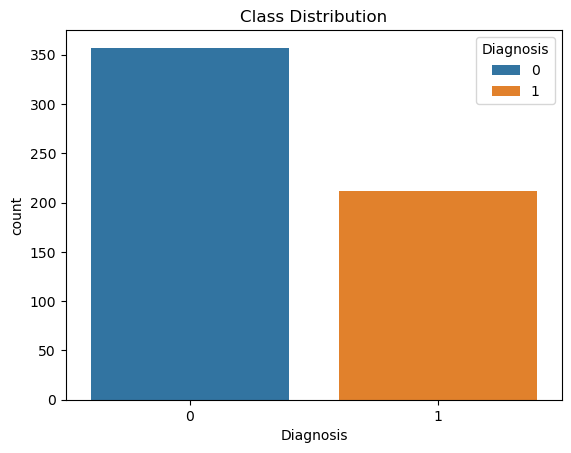

In [16]:

#df['Diagnosis'].value_counts(normalize=True) * 100
sns.countplot(x="Diagnosis",data=df,hue='Diagnosis')
plt.title("Class Distribution")
plt.show()

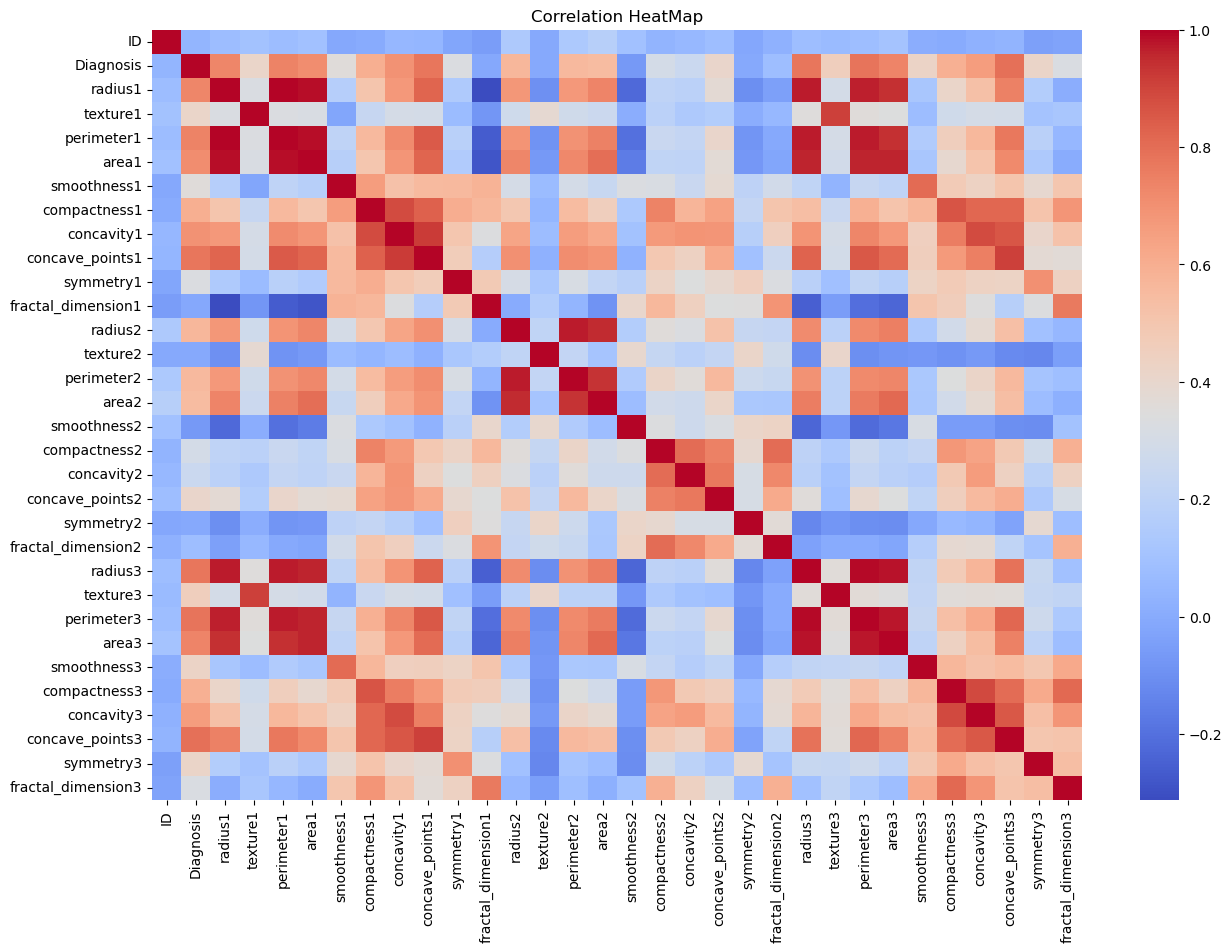

In [6]:
corr = df.corr()

plt.figure(figsize=(15,10))

sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()


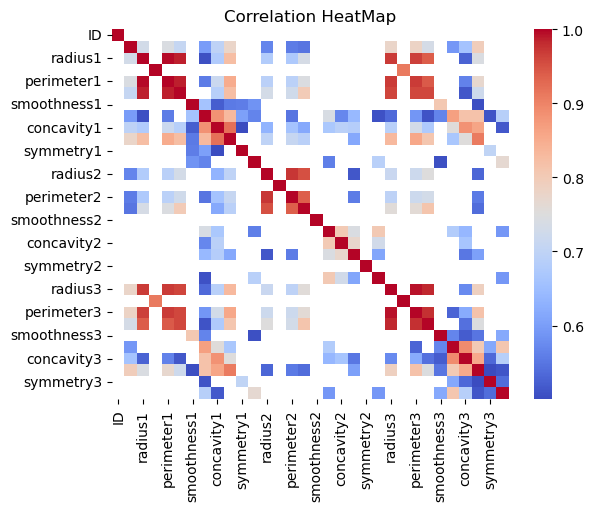

In [7]:
filtered_corr= corr.copy()
filtered_corr[(corr <0.50) & (corr > -0.50)] = np.nan
sns.heatmap(filtered_corr,cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()

In [8]:
X = df.drop(["ID", "Diagnosis"], axis=1)
Y = df["Diagnosis"]
X_train , X_test,Y_train, Y_test  = train_test_split(
    X,Y,test_size=0.2,random_state=42
)


In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt_param_grid= {
    "criterion" : ['gini','entropy'],
    "max_depth" : [None, 5,10,20],
    "min_samples_split" : [2,5,8,10],
    "min_samples_leaf"  : [1,2,3,4] 
 }

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
dt_grid= GridSearchCV(
    dt,
    dt_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
dt_grid.fit(X_train,Y_train)
print(dt_grid.best_params_)
best_dt = dt_grid.best_estimator_
dt_cv_scores = cross_val_score(best_dt,X_train,Y_train,cv=cv,scoring='accuracy')
print("Decision Tree 5-Fold CV Accuracy: ",dt_cv_scores)
print("Average CV Accuracy:", np.mean(dt_cv_scores))

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Decision Tree 5-Fold CV Accuracy:  [0.97802198 0.94505495 0.91208791 0.95604396 0.91208791]
Average CV Accuracy: 0.9406593406593406


In [10]:
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "n_estimators" : [50,100,200],
    "max_depth" :[None, 5,10],
    "max_features" : [None, 'sqrt','log2'],
    "bootstrap" : [True,False]

    
}
rf_grid = GridSearchCV(rf,rf_param_grid,cv=cv,scoring='accuracy',n_jobs=-1)
rf_grid.fit(X_train,Y_train)
best_rf = rf_grid.best_estimator_
print(rf_grid.best_params_)
rf_cv_scores = cross_val_score(best_rf, X_train, Y_train, cv=cv, scoring="accuracy")
print("Random Forest 5-Fold CV Accuracy:", rf_cv_scores)
print("Average CV Accuracy:", np.mean(rf_cv_scores))

{'bootstrap': True, 'max_depth': None, 'max_features': None, 'n_estimators': 50}
Random Forest 5-Fold CV Accuracy: [0.98901099 0.95604396 0.94505495 0.93406593 0.97802198]
Average CV Accuracy: 0.9604395604395606


In [11]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n", model_name, "Evaluation Metrics")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


evaluate_model(best_dt, X_test, Y_test, "Decision Tree")
evaluate_model(best_rf, X_test, Y_test, "Random Forest")



print("\n5-Fold Cross Validation Comparison")
print("Decision Tree Average Accuracy:", np.mean(dt_cv_scores))
print("Random Forest Average Accuracy:", np.mean(rf_cv_scores))


 Decision Tree Evaluation Metrics
Accuracy: 0.9473684210526315
Precision: 0.9302325581395349
Recall: 0.9302325581395349
F1-Score: 0.9302325581395349
ROC-AUC: 0.9354733049459547
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


 Random Forest Evaluation Metrics
Accuracy: 0.956140350877193
Precision: 0.9523809523809523
Recall: 0.9302325581395349
F1-Score: 0.9411764705882353
ROC-AUC: 0.9909924664264658
Confusion Matrix:
 [[69  2]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                  

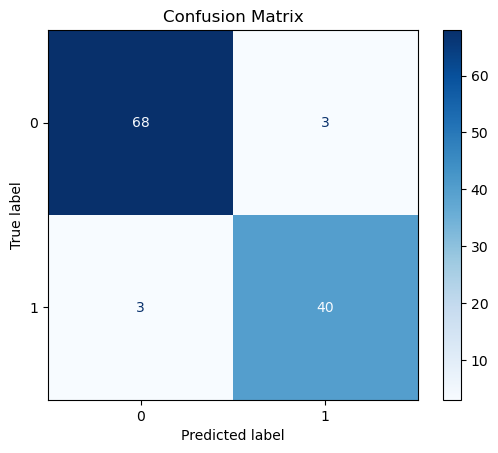

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_dt = best_dt.predict(X_test)
cm = confusion_matrix(Y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

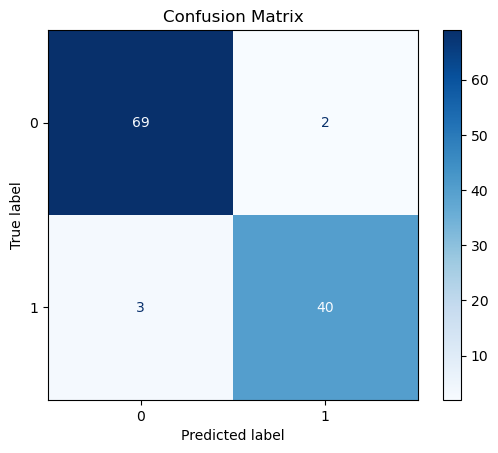

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = best_rf.predict(X_test)
cm = confusion_matrix(Y_test,y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

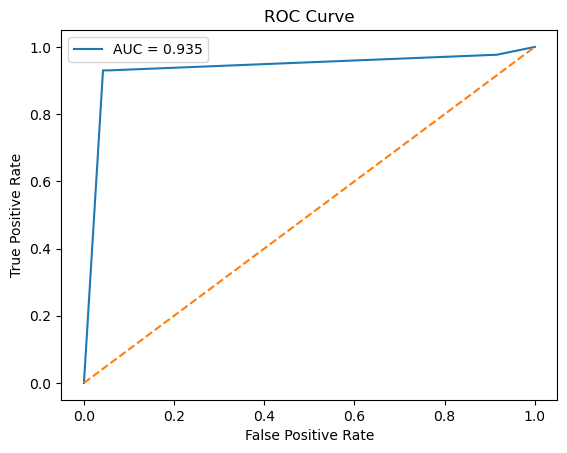

In [14]:
from sklearn.metrics import roc_curve,auc
y_prob_dt = best_dt.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(Y_test,y_prob_dt)

roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

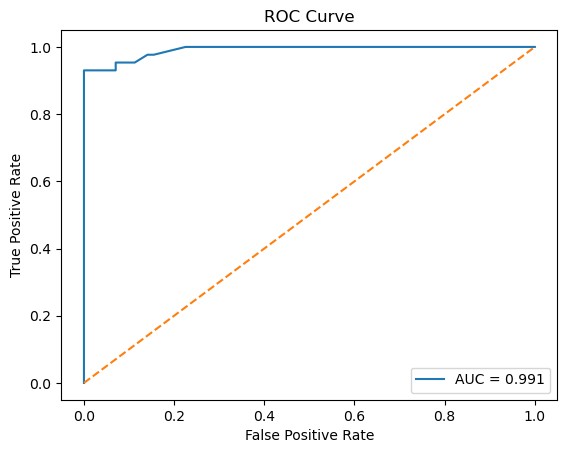

In [15]:
from sklearn.metrics import roc_curve,auc
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(Y_test,y_prob_rf)

roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()